# GenEval-Only Notebook

This notebook keeps only the official GenEval evaluation flow in 3 code cells:
1. Setup and model/critic loading
2. Notebook defaults
3. GenEval generation + official evaluation


In [2]:
import os
import json
import re
import subprocess
import sys
from collections import defaultdict
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import torch
import open_clip
from modeling.tatitok import TATiTok
from modeling.maskgen import MaskGen_VQ

HF_CACHE_DIR = os.path.abspath(os.environ.get('HF_CACHE_DIR', 'hf_cache'))
LOCAL_FILES_ONLY = bool(HF_CACHE_DIR)
os.makedirs(HF_CACHE_DIR, exist_ok=True)
os.environ['HF_HOME'] = HF_CACHE_DIR
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_CACHE_DIR
os.environ['OPENCLIP_CACHE_DIR'] = HF_CACHE_DIR
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('HF cache:', HF_CACHE_DIR)
print('LOCAL_FILES_ONLY:', LOCAL_FILES_ONLY)

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import importlib
import token_regrate.nn as _token_regret_nn
import token_regrate.utils as _token_regret_utils
import token_regrate.train_token_regret_ddp as _token_regret_train
importlib.reload(_token_regret_nn)
importlib.reload(_token_regret_utils)
importlib.reload(_token_regret_train)
from token_regrate.train_token_regret_ddp import *


def load_pretrained_stack(root_dir=HF_CACHE_DIR):
    tok_dir = os.path.join(root_dir, 'turkeyju/tokenizer_tatitok_bl128_vq')
    gen_dir = os.path.join(root_dir, 'turkeyju/generator_maskgen_vq_xl')

    print('Loading TA-TiTok tokenizer...')
    tatitok_vq_tokenizer = TATiTok.from_pretrained(pretrained_model_name_or_path=tok_dir, cache_dir=tok_dir)
    tatitok_vq_tokenizer.eval()
    tatitok_vq_tokenizer.requires_grad_(False)

    print('Loading MaskGen-VQ generator...')
    maskgen_vq_generator = MaskGen_VQ.from_pretrained(pretrained_model_name_or_path=gen_dir, cache_dir=gen_dir)
    maskgen_vq_generator.eval()
    maskgen_vq_generator.requires_grad_(False)

    print('Loading CLIP text encoder...')
    clip_encoder, _, _ = open_clip.create_model_and_transforms(
        'ViT-L-14-336', pretrained='openai', force_quick_gelu=True
    )
    del clip_encoder.visual
    clip_tokenizer = open_clip.get_tokenizer('ViT-L-14-336')
    clip_encoder.transformer.batch_first = False
    clip_encoder.eval()
    clip_encoder.requires_grad_(False)

    print('Pretrained stack ready.')
    return tatitok_vq_tokenizer, maskgen_vq_generator, clip_tokenizer, clip_encoder


tatitok_vq_tokenizer, maskgen_vq_generator, clip_tokenizer, clip_encoder = load_pretrained_stack()
maskgen_vq_generator = maskgen_vq_generator.to(device)
tatitok_vq_tokenizer = tatitok_vq_tokenizer.to(device)
clip_encoder = clip_encoder.to(device)
print('Generator device:', next(maskgen_vq_generator.parameters()).device)
print('Tokenizer device:', next(tatitok_vq_tokenizer.parameters()).device)
print('CLIP text encoder device:', next(clip_encoder.parameters()).device)


attention mode is flash
Using device: cuda
HF cache: /home/behzad/MaskGen/hf_cache
LOCAL_FILES_ONLY: True
Loading TA-TiTok tokenizer...
Loading weights from local directory
Loading MaskGen-VQ generator...
Loading weights from local directory
Loading CLIP text encoder...
Pretrained stack ready.
Generator device: cuda:0
Tokenizer device: cuda:0
CLIP text encoder device: cuda:0


In [3]:
# Load notebook defaults directly from token_regrate/config.py.
CONFIG = get_config()
INF_CFG = CONFIG.inference
TRAIN_CFG = CONFIG.training
RUNTIME_CFG = CONFIG.runtime
MODEL = CONFIG.model

print('Notebook config loaded from token_regrate/config.py')
print('Inference steps:', MODEL.sample_steps)
print('Training batch size:', TRAIN_CFG.per_gpu_batch_size)
print('Training output dir:', CONFIG.experiment.output_dir)
print('DDP only:', bool(TRAIN_CFG.ddp_only))


critic_head = load_trained_critic(RUNTIME_CFG.resume_checkpoint, maskgen_vq_generator, use_hidden=True)
model_device = next(maskgen_vq_generator.parameters()).device
critic_head = critic_head.to(model_device)
print(f'Loaded critic head from: {RUNTIME_CFG.resume_checkpoint}')


GENEVAL_OUTPUT_ROOT = os.path.abspath(
    os.environ.get('GENEVAL_OUTPUT_ROOT', os.path.join('outputs', 'geneval_eval'))
)
os.makedirs(GENEVAL_OUTPUT_ROOT, exist_ok=True)
print('GenEval output root:', GENEVAL_OUTPUT_ROOT)

GENEVAL = {
    'root': 'geneval',
    'output_root': GENEVAL_OUTPUT_ROOT,
    'max_prompts': None,
    'batch_size': 4,
    'seed': int(INF_CFG.seed),
    'guidance_scale': float(TRAIN_CFG.train_guidance_scale),
    'randomize_temperature': 2.0,
    'aesthetic_score': float(TRAIN_CFG.train_aesthetic_score),
    'num_sample_steps': int(MODEL.sample_steps),
    'remask_ratio': float(INF_CFG.remask_ratio),
    'refine_start_step': int(INF_CFG.refine_start_step),
    'refine_loops': int(getattr(INF_CFG, 'refine_loops', TRAIN_CFG.refine_loops)),
    'refine_softmax_temperature': 0.7,
    'critic_use_hidden': True,
    'repair_greedy': False,
    'generation_gpus': [0, 1],
    'parallel_generation_worker_script': os.path.join(PROJECT_ROOT, 'geneval_parallel.py'),
    'run_generation': True,
}


Notebook config loaded from token_regrate/config.py
Inference steps: 16
Training batch size: 128
Training output dir: outputs/token_regret_critic_tanh
DDP only: False
Loaded critic head from: outputs/token_regret_critic_tanh/critic_last.pt
GenEval output root: /home/behzad/MaskGen/outputs/geneval_eval


Using cached GenEval results: /home/behzad/MaskGen/outputs/geneval_eval/baseline_results.jsonl
Summary
Total images: 2212
Total prompts: 553
% correct images: 46.97%
% correct prompts: 60.94%

Task breakdown
color_attr       = 17.50% (70 / 400)
position         = 7.25% (29 / 400)
colors           = 80.32% (302 / 376)
single_object    = 96.88% (310 / 320)
counting         = 39.06% (125 / 320)
two_object       = 51.26% (203 / 396)

Overall score (avg. over tasks): 0.48712
Using cached GenEval results: /home/behzad/MaskGen/outputs/geneval_eval/head_results.jsonl
Summary
Total images: 2212
Total prompts: 553
% correct images: 47.88%
% correct prompts: 63.11%

Task breakdown
color_attr       = 18.50% (74 / 400)
position         = 8.50% (34 / 400)
colors           = 82.45% (310 / 376)
single_object    = 97.81% (313 / 320)
counting         = 38.75% (124 / 320)
two_object       = 51.52% (204 / 396)

Overall score (avg. over tasks): 0.49587
GenEval prompt-level any-of-4 evaluation summary
Basel

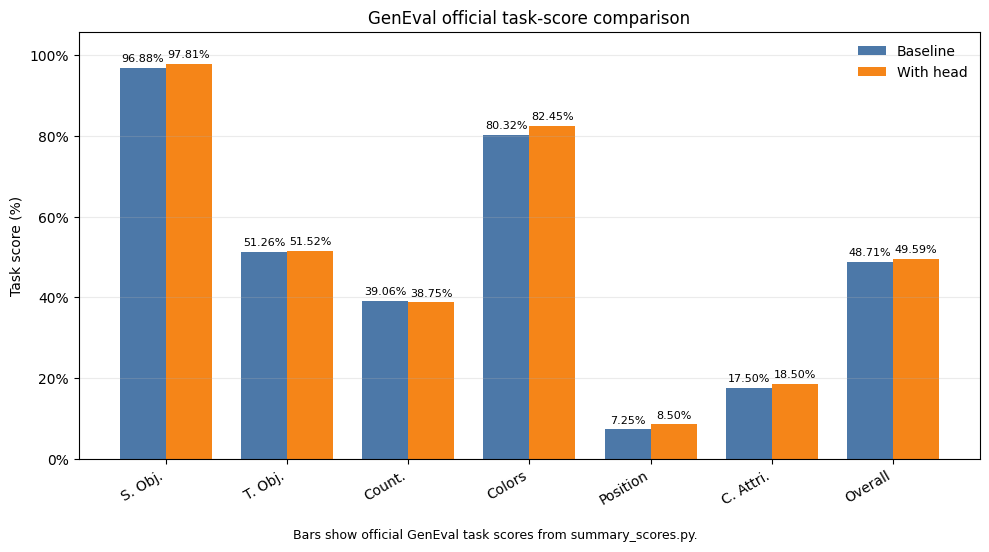

Prompt-level any-of-4 metrics prepared for plotting:
  Baseline prompt-level any-of-4 overall: 0.6261
  With head prompt-level any-of-4 overall: 0.6460
Saved comparison plot: /home/behzad/MaskGen/outputs/geneval_eval/comparison_baseline_vs_head_prompt_level_any4.png


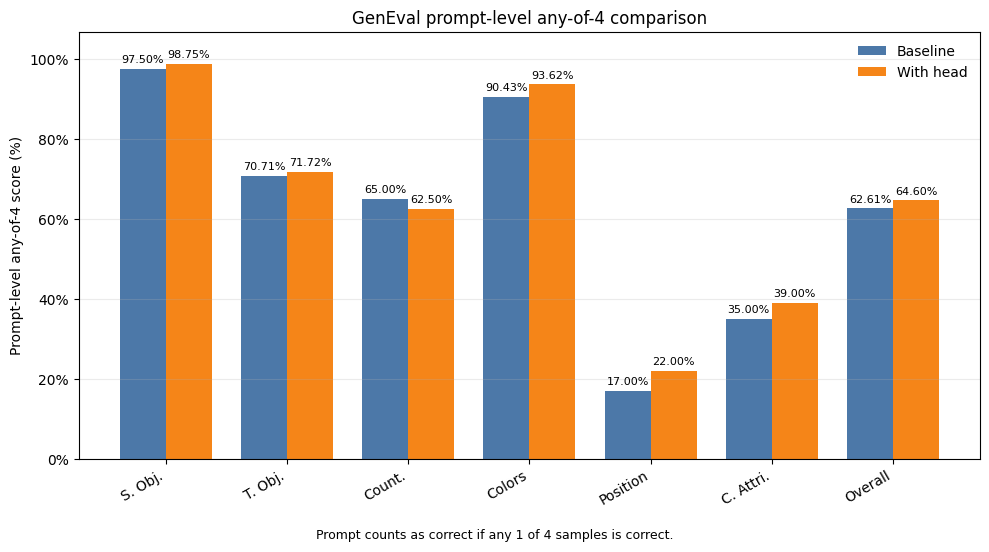

In [24]:
GENEVAL_TASK_ORDER = ['single_object', 'two_object', 'counting', 'colors', 'position', 'color_attr']
GENEVAL_LABELS = {
    'single_object': 'S. Obj.',
    'two_object': 'T. Obj.',
    'counting': 'Count.',
    'colors': 'Colors',
    'position': 'Position',
    'color_attr': 'C. Attri.',
}


def geneval_paths(root='geneval'):
    root = os.path.abspath(root)
    paths = {
        'root': root,
        'eval_script': os.path.join(root, 'evaluation', 'evaluate_images.py'),
        'summary_script': os.path.join(root, 'evaluation', 'summary_scores.py'),
        'metadata_jsonl': os.path.join(root, 'prompts', 'evaluation_metadata.jsonl'),
        'model_path': os.path.join(root, 'saved_models'),
        'model_config': os.path.join(
            root,
            'mmdetection',
            'configs',
            'mask2former',
            'mask2former_swin-s-p4-w7-224_lsj_8x2_50e_coco.py',
        ),
    }
    missing = [name for name, value in paths.items() if not os.path.exists(value)]
    if missing:
        raise FileNotFoundError('Missing GenEval assets:\n' + '\n'.join(f'- {k}: {paths[k]}' for k in missing))
    return paths


def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]


def expected_geneval_counts(metadata_jsonl, batch_size=4, max_prompts=None):
    metadata = load_jsonl(metadata_jsonl)
    if max_prompts is not None:
        metadata = metadata[:max(1, int(max_prompts))]
    tag_prompt_counts = defaultdict(int)
    for row in metadata:
        tag_prompt_counts[row['tag']] += 1
    return {
        'prompt_count': len(metadata),
        'row_count': len(metadata) * int(batch_size),
        'tag_row_counts': {tag: count * int(batch_size) for tag, count in tag_prompt_counts.items()},
    }


def validate_result_rows(rows, metadata_jsonl, batch_size=4, max_prompts=None):
    expected = expected_geneval_counts(metadata_jsonl, batch_size=batch_size, max_prompts=max_prompts)
    tag_counts = defaultdict(int)
    prompt_keys = set()
    for row in rows:
        tag_counts[row['tag']] += 1
        prompt_keys.add(row['metadata'])
    problems = []
    if len(rows) != expected['row_count']:
        problems.append(f"row_count expected {expected['row_count']}, found {len(rows)}")
    if len(prompt_keys) != expected['prompt_count']:
        problems.append(f"prompt_count expected {expected['prompt_count']}, found {len(prompt_keys)}")
    if dict(tag_counts) != expected['tag_row_counts']:
        problems.append(f"tag_row_counts expected {expected['tag_row_counts']}, found {dict(tag_counts)}")
    return problems


def prompt_level_any4_summary(rows):
    by_prompt = {}
    for row in rows:
        key = (row['tag'], row['metadata'])
        by_prompt.setdefault(key, []).append(bool(row.get('correct', False)))

    by_tag = defaultdict(list)
    for (tag, _), flags in by_prompt.items():
        by_tag[tag].append(float(any(flags)))

    tag_scores = {tag: float(sum(values) / len(values)) for tag, values in by_tag.items()}
    return {
        'protocol': 'prompt_level_any_of_4',
        'overall_prompt_level': float(sum(tag_scores.values()) / len(tag_scores)),
        'tag_scores': tag_scores,
        'num_rows': len(rows),
        'num_prompts': len(by_prompt),
    }


def parse_official_geneval_summary(summary_text):
    scores = {}
    overall = None
    totals = {}
    task_pattern = re.compile(r'^\s*([a-z_]+)\s*=\s*([0-9.]+)%\s*\((\d+)\s*/\s*(\d+)\)\s*$')
    total_patterns = {
        'total_images': re.compile(r'^Total images:\s*(\d+)\s*$'),
        'total_prompts': re.compile(r'^Total prompts:\s*(\d+)\s*$'),
        'percent_correct_images': re.compile(r'^% correct images:\s*([0-9.]+)%\s*$'),
        'percent_correct_prompts': re.compile(r'^% correct prompts:\s*([0-9.]+)%\s*$'),
    }
    for line in str(summary_text or '').splitlines():
        task_match = task_pattern.match(line)
        if task_match:
            tag, pct, correct, total = task_match.groups()
            scores[tag] = {
                'score': float(pct) / 100.0,
                'percent': float(pct),
                'correct': int(correct),
                'total': int(total),
            }
            continue
        for key, pattern in total_patterns.items():
            match = pattern.match(line.strip())
            if match:
                value = match.group(1)
                totals[key] = float(value) if 'percent' in key else int(value)
                break
        if 'Overall score' in line:
            try:
                overall = float(line.rsplit(':', 1)[-1].strip())
            except ValueError:
                pass
    return {
        'overall_score_avg_over_tasks': overall,
        'task_scores': scores,
        **totals,
    }


def write_prompt_summary(out_file, summary, official_summary_text=''):
    summary = dict(summary)
    summary['outfile'] = out_file
    official_summary = parse_official_geneval_summary(official_summary_text)
    if official_summary['task_scores'] or official_summary['overall_score_avg_over_tasks'] is not None:
        summary['official_geneval'] = official_summary
    summary_path = os.path.splitext(out_file)[0] + '_prompt_level_any4_summary.json'
    with open(summary_path, 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    return summary_path, summary


def evaluator_env(cuda_visible_devices=None):
    env = os.environ.copy()
    env['GENEVAL_USE_ABSOLUTE_IMPORTS'] = '1'
    env['PYTHONPATH'] = os.pathsep.join([PROJECT_ROOT, env.get('PYTHONPATH', '')]).rstrip(os.pathsep)
    if cuda_visible_devices is not None:
        env['CUDA_VISIBLE_DEVICES'] = str(cuda_visible_devices)
    return env


def resolve_geneval_eval_python():
    candidates = [
        os.environ.get('GENEVAL_EVAL_PYTHON', ''),
        '/home/behzad/anaconda3/envs/geneval/bin/python',
        os.path.expanduser('~/anaconda3/envs/geneval/bin/python'),
        os.path.expanduser('~/miniconda3/envs/geneval/bin/python'),
        sys.executable,
    ]
    for candidate in candidates:
        candidate = str(candidate).strip()
        if not candidate:
            continue
        candidate = os.path.abspath(os.path.expanduser(candidate))
        if not os.path.isfile(candidate) or not os.access(candidate, os.X_OK):
            continue
        probe = subprocess.run(
            [candidate, '-c', 'import mmcv, mmdet; print(mmcv.__version__); print(mmdet.__version__)'],
            capture_output=True,
            text=True,
        )
        if probe.returncode == 0:
            return candidate
    raise RuntimeError('Could not resolve a valid GenEval evaluator Python.')


def run_official_geneval_eval(eval_dir, out_file, geneval_root='geneval', eval_python=sys.executable):
    paths = geneval_paths(geneval_root)
    if not os.path.isdir(eval_dir):
        raise FileNotFoundError('GenEval image directory not found: ' + str(eval_dir))

    env = evaluator_env()
    stderr_log = os.path.splitext(out_file)[0] + '_eval_stderr.log'
    cmd = [
        eval_python,
        paths['eval_script'],
        eval_dir,
        '--outfile',
        out_file,
        '--model-path',
        paths['model_path'],
        '--options',
        f"model_config={paths['model_config']}",
    ]
    print('Running official GenEval evaluator...')
    result = subprocess.run(cmd, env=env, capture_output=True, text=True)
    with open(stderr_log, 'w', encoding='utf-8') as f:
        f.write(result.stderr or '')
    if result.stdout.strip():
        print(result.stdout.strip())
    if result.returncode != 0:
        if result.stderr.strip():
            print(result.stderr.strip()[-4000:])
        raise RuntimeError('Official GenEval evaluator failed.')

    summary_cmd = [eval_python, paths['summary_script'], out_file]
    summary_run = subprocess.run(summary_cmd, env=env, capture_output=True, text=True)
    if summary_run.stdout.strip():
        print(summary_run.stdout.strip())

    rows = load_jsonl(out_file)
    summary_path, prompt_summary = write_prompt_summary(out_file, prompt_level_any4_summary(rows), summary_run.stdout)
    return {
        'results_jsonl': out_file,
        'prompt_level_any4_summary_json': summary_path,
        'paper_protocol_summary_json': summary_path,
        'paper_protocol': prompt_summary,
        'summary_scores_stdout': summary_run.stdout,
        'evaluation_stdout': result.stdout,
        'evaluation_stderr_log': stderr_log,
    }


def load_existing_eval_report(out_file, metadata_jsonl, geneval_root='geneval', eval_python=sys.executable, batch_size=4, max_prompts=None):
    if not os.path.isfile(out_file):
        return None
    rows = load_jsonl(out_file)
    problems = validate_result_rows(rows, metadata_jsonl, batch_size=batch_size, max_prompts=max_prompts)
    if problems:
        print(f"Ignoring cached GenEval results for {out_file}: " + '; '.join(problems))
        return None

    print(f'Using cached GenEval results: {out_file}')
    paths = geneval_paths(geneval_root)
    summary_run = subprocess.run(
        [eval_python, paths['summary_script'], out_file],
        env=evaluator_env(),
        capture_output=True,
        text=True,
    )
    if summary_run.stdout.strip():
        print(summary_run.stdout.strip())

    summary_path, prompt_summary = write_prompt_summary(out_file, prompt_level_any4_summary(rows), summary_run.stdout)
    return {
        'results_jsonl': out_file,
        'prompt_level_any4_summary_json': summary_path,
        'paper_protocol_summary_json': summary_path,
        'paper_protocol': prompt_summary,
        'summary_scores_stdout': summary_run.stdout,
        'evaluation_stdout': '',
        'evaluation_stderr_log': '',
    }


def generation_config(use_regret_remask, batch_size, max_prompts, seed, guidance_scale, randomize_temperature,
                      aesthetic_score, num_sample_steps, remask_ratio, refine_start_step, refine_loops,
                      critic_use_hidden, refine_softmax_temperature, repair_greedy):
    config = {
        'batch_size': int(batch_size),
        'max_prompts': None if max_prompts is None else int(max_prompts),
        'seed': int(seed),
        'seed_policy': 'fixed_per_prompt',
        'guidance_scale': float(guidance_scale),
        'randomize_temperature': float(randomize_temperature),
        'aesthetic_score': float(aesthetic_score),
        'num_sample_steps': int(num_sample_steps),
        'use_regret_remask': bool(use_regret_remask),
    }
    if use_regret_remask:
        config.update({
            'remask_ratio': float(remask_ratio),
            'refine_start_step': int(refine_start_step),
            'refine_loops': None if refine_loops is None else int(refine_loops),
            'critic_use_hidden': bool(critic_use_hidden),
            'refine_softmax_temperature': float(refine_softmax_temperature),
            'repair_greedy': bool(repair_greedy),
        })
    return config


def image_cache_ready(image_dir, expected_prompt_count, batch_size, expected_config):
    image_dir = os.path.abspath(image_dir)
    if not os.path.isdir(image_dir):
        return False

    config_path = os.path.join(image_dir, 'generation_config.json')
    if not os.path.isfile(config_path):
        print(f'Ignoring cached GenEval images in {image_dir}; missing generation_config.json')
        return False
    with open(config_path, 'r', encoding='utf-8') as f:
        existing_config = json.load(f)
    mismatches = [key for key, value in expected_config.items() if existing_config.get(key) != value]
    if mismatches:
        print(f'Ignoring cached GenEval images in {image_dir}; generation_config mismatch: ' + ', '.join(mismatches))
        return False

    valid_prompts = 0
    for name in os.listdir(image_dir):
        prompt_dir = os.path.join(image_dir, name)
        samples_dir = os.path.join(prompt_dir, 'samples')
        if not (name.isdigit() and os.path.isfile(os.path.join(prompt_dir, 'metadata.jsonl')) and os.path.isdir(samples_dir)):
            continue
        sample_count = sum(1 for x in os.listdir(samples_dir) if x.lower().endswith('.png') and x[:-4].isdigit())
        if sample_count >= int(batch_size):
            valid_prompts += 1
    return valid_prompts >= int(expected_prompt_count)


def worker_command(mode, outdir, geneval_root, resume_checkpoint, hf_cache_dir, cfg):
    cmd = [
        sys.executable,
        os.path.abspath(GENEVAL['parallel_generation_worker_script']),
        '--mode', mode,
        '--geneval-root', geneval_root,
        '--output-dir', outdir,
        '--hf-cache-dir', hf_cache_dir,
        '--batch-size', str(cfg['batch_size']),
        '--seed', str(cfg['seed']),
        '--guidance-scale', str(cfg['guidance_scale']),
        '--randomize-temperature', str(cfg['randomize_temperature']),
        '--aesthetic-score', str(cfg['aesthetic_score']),
        '--num-sample-steps', str(cfg['num_sample_steps']),
    ]
    if cfg['max_prompts'] is not None:
        cmd += ['--max-prompts', str(cfg['max_prompts'])]
    if mode == 'head':
        cmd += [
            '--resume-checkpoint', str(resume_checkpoint),
            '--remask-ratio', str(cfg['remask_ratio']),
            '--refine-start-step', str(cfg['refine_start_step']),
            '--critic-use-hidden',
            '--refine-softmax-temperature', str(cfg['refine_softmax_temperature']),
        ]
        if cfg['refine_loops'] is not None:
            cmd += ['--refine-loops', str(cfg['refine_loops'])]
        if cfg['repair_greedy']:
            cmd += ['--repair-greedy']
    return cmd


def run_generation_worker(job, gpu, geneval_root, resume_checkpoint, hf_cache_dir, cfg):
    env = os.environ.copy()
    env['CUDA_VISIBLE_DEVICES'] = str(gpu)
    env['HF_HOME'] = hf_cache_dir
    env['HUGGINGFACE_HUB_CACHE'] = hf_cache_dir
    env['OPENCLIP_CACHE_DIR'] = hf_cache_dir
    env['PYTHONPATH'] = os.pathsep.join([PROJECT_ROOT, env.get('PYTHONPATH', '')]).rstrip(os.pathsep)
    cmd = worker_command(job['mode'], job['outdir'], geneval_root, resume_checkpoint, hf_cache_dir, cfg)
    print(f"Launching {job['mode']} generation on GPU {gpu}: {job['outdir']}")
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_ROOT)


def generate_missing_images(jobs, generation_gpus, geneval_root, resume_checkpoint, hf_cache_dir, configs):
    if len(jobs) > 1 and len(generation_gpus) >= len(jobs):
        modules = [maskgen_vq_generator, tatitok_vq_tokenizer, clip_encoder]
        if critic_head is not None:
            modules.append(critic_head)
        original_device = next(maskgen_vq_generator.parameters()).device
        for module in modules:
            module.to('cpu')
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        try:
            procs = [
                run_generation_worker(job, generation_gpus[idx], geneval_root, resume_checkpoint, hf_cache_dir, configs[job['mode']])
                for idx, job in enumerate(jobs)
            ]
            failures = []
            for job, proc in zip(jobs, procs):
                code = proc.wait()
                if code != 0:
                    failures.append((job['mode'], code))
            if failures:
                raise RuntimeError(f'Parallel GenEval generation failed: {failures}')
        finally:
            for module in modules:
                module.to(original_device)
        return

    from geneval_parallel import generate_geneval_images_maskgen

    for job in jobs:
        is_head = job['mode'] == 'head'
        cfg = configs[job['mode']]
        generate_geneval_images_maskgen(
            model=maskgen_vq_generator,
            tokenizer=tatitok_vq_tokenizer,
            clip_tokenizer=clip_tokenizer,
            clip_encoder=clip_encoder,
            metadata_jsonl=geneval_paths(geneval_root)['metadata_jsonl'],
            outdir=job['outdir'],
            batch_size=cfg['batch_size'],
            max_prompts=cfg['max_prompts'],
            seed=cfg['seed'],
            guidance_scale=cfg['guidance_scale'],
            randomize_temperature=cfg['randomize_temperature'],
            aesthetic_score=cfg['aesthetic_score'],
            num_sample_steps=cfg['num_sample_steps'],
            use_regret_remask=is_head,
            critic=critic_head if is_head else None,
            remask_ratio=cfg.get('remask_ratio', GENEVAL['remask_ratio']),
            refine_start_step=cfg.get('refine_start_step', GENEVAL['refine_start_step']),
            refine_loops=cfg.get('refine_loops', GENEVAL['refine_loops']),
            critic_use_hidden=cfg.get('critic_use_hidden', GENEVAL['critic_use_hidden']),
            refine_softmax_temperature=cfg.get('refine_softmax_temperature', GENEVAL['refine_softmax_temperature']),
            repair_greedy=cfg.get('repair_greedy', GENEVAL['repair_greedy']),
        )


def print_prompt_summary(label, summary):
    print(f"{label}: prompt_level_any_of_4={summary['overall_prompt_level']:.4f}")
    scores = summary['tag_scores']
    for tag in [t for t in GENEVAL_TASK_ORDER if t in scores] + [t for t in scores if t not in GENEVAL_TASK_ORDER]:
        print(f'  {tag:<16} {scores[tag]:.4f}')


def run_geneval_cached(geneval_root, output_root, eval_python, run_generation=True):
    paths = geneval_paths(geneval_root)
    output_root = os.path.abspath(output_root)
    os.makedirs(output_root, exist_ok=True)

    baseline_dir = os.path.join(output_root, 'baseline_images')
    head_dir = os.path.join(output_root, 'head_images')
    baseline_results = os.path.join(output_root, 'baseline_results.jsonl')
    head_results = os.path.join(output_root, 'head_results.jsonl')

    common_cfg = dict(
        batch_size=GENEVAL['batch_size'],
        max_prompts=GENEVAL['max_prompts'],
        seed=GENEVAL['seed'],
        guidance_scale=GENEVAL['guidance_scale'],
        randomize_temperature=GENEVAL['randomize_temperature'],
        aesthetic_score=GENEVAL['aesthetic_score'],
        num_sample_steps=GENEVAL['num_sample_steps'],
        remask_ratio=GENEVAL['remask_ratio'],
        refine_start_step=GENEVAL['refine_start_step'],
        refine_loops=GENEVAL['refine_loops'],
        critic_use_hidden=GENEVAL['critic_use_hidden'],
        refine_softmax_temperature=GENEVAL['refine_softmax_temperature'],
        repair_greedy=GENEVAL['repair_greedy'],
    )
    configs = {
        'baseline': generation_config(False, **common_cfg),
        'head': generation_config(True, **common_cfg),
    }
    expected_prompt_count = expected_geneval_counts(
        paths['metadata_jsonl'],
        batch_size=GENEVAL['batch_size'],
        max_prompts=GENEVAL['max_prompts'],
    )['prompt_count']

    baseline_eval = load_existing_eval_report(
        baseline_results, paths['metadata_jsonl'], geneval_root, eval_python,
        batch_size=GENEVAL['batch_size'], max_prompts=GENEVAL['max_prompts'],
    )
    head_eval = load_existing_eval_report(
        head_results, paths['metadata_jsonl'], geneval_root, eval_python,
        batch_size=GENEVAL['batch_size'], max_prompts=GENEVAL['max_prompts'],
    )

    jobs = []
    if baseline_eval is None and not image_cache_ready(baseline_dir, expected_prompt_count, GENEVAL['batch_size'], configs['baseline']):
        jobs.append({'mode': 'baseline', 'outdir': baseline_dir})
    if head_eval is None and not image_cache_ready(head_dir, expected_prompt_count, GENEVAL['batch_size'], configs['head']):
        jobs.append({'mode': 'head', 'outdir': head_dir})

    if jobs:
        if not run_generation:
            raise RuntimeError(f"Missing reusable GenEval images/results for {[job['mode'] for job in jobs]} and run_generation=False.")
        generate_missing_images(
            jobs,
            generation_gpus=list(GENEVAL.get('generation_gpus') or []),
            geneval_root=geneval_root,
            resume_checkpoint=RUNTIME_CFG.resume_checkpoint,
            hf_cache_dir=HF_CACHE_DIR,
            configs=configs,
        )

    if baseline_eval is None:
        baseline_eval = run_official_geneval_eval(baseline_dir, baseline_results, geneval_root, eval_python)
    if head_eval is None:
        head_eval = run_official_geneval_eval(head_dir, head_results, geneval_root, eval_python)

    comparison = {
        'baseline_overall_prompt_level': baseline_eval['paper_protocol']['overall_prompt_level'],
        'head_overall_prompt_level': head_eval['paper_protocol']['overall_prompt_level'],
        'delta_head_minus_baseline': (
            head_eval['paper_protocol']['overall_prompt_level']
            - baseline_eval['paper_protocol']['overall_prompt_level']
        ),
        'baseline_tag_scores': baseline_eval['paper_protocol']['tag_scores'],
        'head_tag_scores': head_eval['paper_protocol']['tag_scores'],
    }
    comparison_path = os.path.join(output_root, 'comparison_baseline_vs_head.json')
    with open(comparison_path, 'w', encoding='utf-8') as f:
        json.dump(comparison, f, indent=2)

    print('GenEval prompt-level any-of-4 evaluation summary')
    print_prompt_summary('Baseline', baseline_eval['paper_protocol'])
    print_prompt_summary('With head', head_eval['paper_protocol'])
    print(f"Prompt-level any-of-4 delta (head - baseline): {comparison['delta_head_minus_baseline']*100:+.2f}")
    print('Saved prompt-level any-of-4 comparison:', comparison_path)

    return {
        'baseline': baseline_eval,
        'head': head_eval,
        'comparison': comparison,
        'comparison_path': comparison_path,
        'baseline_image_dir': baseline_dir,
        'head_image_dir': head_dir,
    }


def plot_baseline_vs_head(baseline_scores, head_scores, baseline_overall, head_overall, title, ylabel, footnote,
                          filename, decimals=2):
    tags = [tag for tag in GENEVAL_TASK_ORDER if tag in baseline_scores or tag in head_scores]
    labels = [GENEVAL_LABELS.get(tag, tag) for tag in tags] + ['Overall']
    baseline_values = [float(baseline_scores.get(tag, np.nan)) for tag in tags] + [float(baseline_overall)]
    head_values = [float(head_scores.get(tag, np.nan)) for tag in tags] + [float(head_overall)]

    x = np.arange(len(labels))
    width = 0.38
    fig, ax = plt.subplots(figsize=(max(10, 1.1 * len(labels)), 5.5))
    ax.bar(x - width / 2, baseline_values, width, label='Baseline', color='#4C78A8')
    ax.bar(x + width / 2, head_values, width, label='With head', color='#F58518')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylim(0, max(1.0, np.nanmax([np.nanmax(baseline_values), np.nanmax(head_values)]) + 0.08))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False)

    for bars in ax.containers:
        ax.bar_label(
            bars,
            labels=['' if not np.isfinite(bar.get_height()) else f'{bar.get_height() * 100:.{decimals}f}%' for bar in bars],
            padding=3,
            fontsize=8,
        )

    fig.text(0.5, 0.01, footnote, ha='center', fontsize=9)
    plt.tight_layout(rect=(0, 0.04, 1, 1))

    plot_path = os.path.join(os.path.dirname(geneval_report['comparison_path']), filename)
    fig.savefig(plot_path, dpi=200, bbox_inches='tight')
    print('Saved comparison plot:', plot_path)
    plt.show()


GENEVAL_EVAL_PYTHON = resolve_geneval_eval_python()
geneval_report = run_geneval_cached(
    geneval_root=GENEVAL['root'],
    output_root=GENEVAL['output_root'],
    eval_python=GENEVAL_EVAL_PYTHON,
    run_generation=GENEVAL['run_generation'],
)
comparison = geneval_report['comparison']

baseline_official_summary = parse_official_geneval_summary(
    geneval_report['baseline'].get('summary_scores_stdout', '')
)
head_official_summary = parse_official_geneval_summary(
    geneval_report['head'].get('summary_scores_stdout', '')
)
baseline_official = baseline_official_summary['task_scores']
head_official = head_official_summary['task_scores']
baseline_official_overall = baseline_official_summary['overall_score_avg_over_tasks']
head_official_overall = head_official_summary['overall_score_avg_over_tasks']
if baseline_official or head_official:
    print('Official GenEval metrics prepared for plotting:')
    print(f'  Baseline overall: {baseline_official_overall:.4f}')
    print(f'  With head overall: {head_official_overall:.4f}')
    plot_baseline_vs_head(
        {tag: values['score'] for tag, values in baseline_official.items()},
        {tag: values['score'] for tag, values in head_official.items()},
        baseline_official_overall,
        head_official_overall,
        title='GenEval official task-score comparison',
        ylabel='Task score (%)',
        footnote='Bars show official GenEval task scores from summary_scores.py.',
        filename='comparison_baseline_vs_head_official_task_score.png',
        decimals=2,
    )

print('Prompt-level any-of-4 metrics prepared for plotting:')
print(f"  Baseline prompt-level any-of-4 overall: {comparison['baseline_overall_prompt_level']:.4f}")
print(f"  With head prompt-level any-of-4 overall: {comparison['head_overall_prompt_level']:.4f}")
plot_baseline_vs_head(
    comparison['baseline_tag_scores'],
    comparison['head_tag_scores'],
    comparison['baseline_overall_prompt_level'],
    comparison['head_overall_prompt_level'],
    title='GenEval prompt-level any-of-4 comparison',
    ylabel='Prompt-level any-of-4 score (%)',
    footnote='Prompt counts as correct if any 1 of 4 samples is correct.',
    filename='comparison_baseline_vs_head_prompt_level_any4.png',
    decimals=2,
)
